In [20]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso  # для штрафа L1

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, make_scorer, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# Пример логистической регрессии

In [21]:
np.random.seed(42)
n_samples = 300
dohod = np.random.randint(30000, 100000, n_samples)
credit_his =  np.random.rand(n_samples)
veroyatno_vydacha_credita  = 0.5 * dohod + 10000 * credit_his + np.random.normal(0, 5000, n_samples)
vydacha_credita  = (veroyatno_vydacha_credita > np.mean(veroyatno_vydacha_credita)).astype(int)
data = pd.DataFrame({'доход': dohod, 'кредитная_история': credit_his, 'выдача_кредита': vydacha_credita})

In [22]:
# Создадим DataFrame
data = pd.DataFrame({'доход': dohod , 'кредитная_история': credit_his, 'выдача_кредита': vydacha_credita})
data

,доход,кредитная_история,выдача_кредита
0,45795,0.590833,0
1,30860,0.030500,0
2,84886,0.037348,1
3,36265,0.822601,0
4,67194,0.360191,1
...,...,...,...
295,40966,0.633401,0
296,82921,0.240146,1
297,79726,0.075863,0
298,80300,0.128880,1


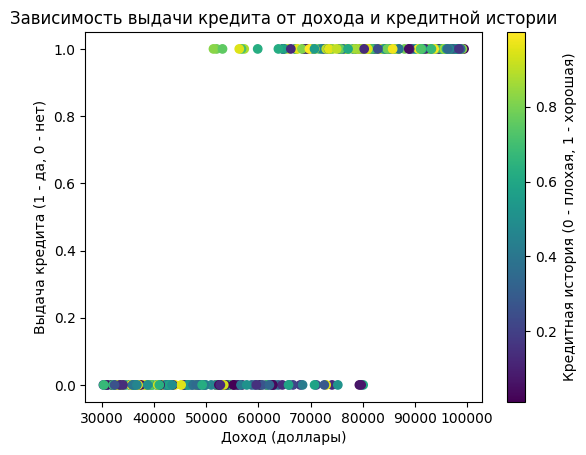

In [23]:
# Визуализируем данные (немного упрощенно, для понимания)
plt.scatter(data['доход'], data['выдача_кредита'], c=data['кредитная_история'], cmap='viridis')
plt.xlabel('Доход (доллары)')
plt.ylabel('Выдача кредита (1 - да, 0 - нет)')
plt.title('Зависимость выдачи кредита от дохода и кредитной истории')
plt.colorbar(label='Кредитная история (0 - плохая, 1 - хорошая)')
plt.show()

In [24]:
#  Подготовим данные для обучения
X = data[['доход', 'кредитная_история']]  # Независимые переменные (признаки)
y = data['выдача_кредита']  # Зависимая переменная (целевая переменная)

# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(160, 2)

In [ ]:
X_test.shape

(40, 2)

In [25]:
#  Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
#  Создадим модель логистической регрессии
model = LogisticRegression()

# Обучим модель на обучающей выборке
model.fit(X_train_scaled, y_train)


LogisticRegression()

In [27]:
#  Сделаем предсказания на train  тестовой выборке
y_pred_t = model.predict(X_train_scaled)  # Предсказание классов (0 или 1)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test)[:, 1]  # Предсказание вероятностей для класса 1

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [28]:
# Оценим качество модели
accuracy_t = accuracy_score(y_train, y_pred_t)
accuracy = accuracy_score(y_test, y_pred)

report_t = classification_report(y_train, y_pred_t)
report = classification_report(y_test, y_pred)


print(f"Точность (train): {accuracy_t:.2f}")
print(f"Отчет о классификации:\n{report_t}")

print(f"Точность (test): {accuracy:.2f}")
print(f"Отчет о классификации:\n{report}")

Точность (train): 0.93
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       115
           1       0.93      0.92      0.93       125

    accuracy                           0.93       240
   macro avg       0.92      0.93      0.92       240
weighted avg       0.93      0.93      0.93       240

Точность (test): 0.87
Отчет о классификации:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87        32
           1       0.83      0.89      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



In [29]:
#  Выведем коэффициенты модели
print(f"Коэффициент b0 (intercept): {model.intercept_[0]:.2f}")
print(f"Коэффициенты b1 (доход) и b2 (кредитная история): {model.coef_[0]}")

Коэффициент b0 (intercept): 0.16
Коэффициенты b1 (доход) и b2 (кредитная история): [3.66852075 0.85180649]


In [30]:
# Пример предсказания для нового клиента
new_dohod = 20000
new_credit_his = 0.2
veroyatno = model.predict_proba([[new_dohod, new_credit_his]])[0, 1]
print(f"\nВероятность выдачи кредита для клиента с доходом {new_dohod} и кредитной историей {new_credit_his}: {veroyatno:.2f}")


Вероятность выдачи кредита для клиента с доходом 20000 и кредитной историей 0.2: 1.00


# Пример L1-регуляризации

In [31]:
#Подготовка данных
X = data[['доход', 'кредитная_история']]  # Признаки
y = data['выдача_кредита']  # Целевая переменная

#Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# Масштабирование признаков (важно для L1-регуляризации)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [37]:
#Создание и обучение модели Lasso (L1-регуляризация)
#Чем больше alpha, тем сильнее регуляризация (тем сильнее штраф за большие коэффициенты).
alpha = 0.5          # Параметр регуляризации (важно настроить)
#C = 1/alpha, так как в LogisticRegression регуляризация выражается через обратную силу.
logistic_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1/alpha, random_state=42)

logistic_lasso.fit(X_train_scaled, y_train)




LogisticRegression(C=2.0, penalty='l1', random_state=42, solver='liblinear')

In [38]:
# Предсказание
y_pred_t = model.predict(X_train_scaled)
y_pred_logistic_lasso = logistic_lasso.predict(X_test_scaled) # Теперь предсказываем классы (0 или 1)

# Оценка модели
accuracy_t = accuracy_score(y_train, y_pred_t)

accuracy_logistic_lasso = accuracy_score(y_test, y_pred_logistic_lasso)
print("\nClassification Report (train):\n", classification_report(y_train, y_pred_t))
print(f"Логистическая регрессия с L1: Accuracy = {accuracy_logistic_lasso:.2f}")
print("\nClassification Report (Логистическая регрессия с L1):\n", classification_report(y_test, y_pred_logistic_lasso))


Classification Report (train):
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       115
           1       0.93      0.92      0.93       125

    accuracy                           0.93       240
   macro avg       0.92      0.93      0.92       240
weighted avg       0.93      0.93      0.93       240

Логистическая регрессия с L1: Accuracy = 0.87

Classification Report (Логистическая регрессия с L1):
               precision    recall  f1-score   support

           0       0.90      0.84      0.87        32
           1       0.83      0.89      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



Важная особенность L1-регуляризации заключается в том, что она может занулять некоторые коэффициенты, тем самым выполняя отбор признаков.  Некоторые коэффициенты могут быть равны 0.

# Логистическая регрессия с GridSearchCV

In [44]:
# Подготовка данных
X = data[['доход', 'кредитная_история']]
y = data['выдача_кредита']
#  Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# Масштабирование признаков (ОЧЕНЬ ВАЖНО для регуляризации)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
#Логистическая регрессия с L1-регуляризацией (Lasso)
# Используем GridSearchCV для поиска оптимального параметра C (обратная сила регуляризации)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}  # Чем меньше C, тем сильнее регуляризация.

grid_search = GridSearchCV(LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
                           param_grid, cv=5, scoring='accuracy') # Используем accuracy для классификации
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(penalty='l1', random_state=42,
                                          solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

In [47]:
# Лучшая модель
best_logistic_lasso = grid_search.best_estimator_
print("Лучшие параметры для логистической регрессии с L1:", grid_search.best_params_)

Лучшие параметры для логистической регрессии с L1: {'C': 1}


In [49]:
#  Оценка модели
y_pred_logistic_lasso_t = best_logistic_lasso.predict(X_train_scaled)
y_pred_logistic_lasso = best_logistic_lasso.predict(X_test_scaled)

accuracy_logistic_lasso = accuracy_score(y_test, y_pred_logistic_lasso)
print(f"Логистическая регрессия с L1: Accuracy = {accuracy_logistic_lasso:.2f}")
print("\nClassification Report (Логистическая регрессия с L1 Train):\n", classification_report(y_train, y_pred_logistic_lasso_t))
print("\nClassification Report (Логистическая регрессия с L1):\n", classification_report(y_test, y_pred_logistic_lasso))

Логистическая регрессия с L1: Accuracy = 0.88

Classification Report (Логистическая регрессия с L1 Train):
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       115
           1       0.93      0.92      0.93       125

    accuracy                           0.93       240
   macro avg       0.92      0.93      0.92       240
weighted avg       0.93      0.93      0.93       240


Classification Report (Логистическая регрессия с L1):
               precision    recall  f1-score   support

           0       0.90      0.88      0.89        32
           1       0.86      0.89      0.88        28

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [50]:
# 7. Предсказание для нового клиента
new_dohod = 60000
new_credit_his = 0.7

new_client = pd.DataFrame({'доход': [new_dohod], 'кредитная_история': [new_credit_his]})
new_client_scaled = scaler.transform(new_client)  # Обязательно масштабируем!

veroyatno = best_logistic_lasso.predict_proba(new_client_scaled)[0, 1]  # Вероятность класса 1
vydacha = best_logistic_lasso.predict(new_client_scaled)[0] # 0 или 1

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_dohod}, Кредитная история: {new_credit_his}")
print(f"Вероятность выдачи кредита: {veroyatno:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {vydacha}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.41
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 0


**Важно помнить:**

* Масштабирование признаков (использование StandardScaler) очень важно для L1-регуляризации.

* Параметр alpha нужно тщательно настраивать, чтобы найти баланс между сложностью модели и ее способностью к обобщению.

* L1-регуляризация может использоваться для отбора признаков, зануляя коэффициенты неважных признаков.

#Пример использование  кроссвалидации и GridSearchCV  с Lasso

In [51]:
#  Подготовка данных
X = data[['доход', 'кредитная_история']]
y = data['выдача_кредита']

#  Разделение на обучающую и тестовую выборки (ТОЛЬКО для финальной оценки)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [52]:
# Масштабирование (ОЧЕНЬ ВАЖНО)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
# 5. Логистическая регрессия с L1-регуляризацией и кросс-валидацией

# Определяем scorer'ы для кросс-валидации (важно для сбалансированных оценок)
scoring = {'accuracy': 'accuracy',
           'precision': make_scorer(precision_score),
           'recall': make_scorer(recall_score),
           'f1': make_scorer(f1_score)}

# GridSearchCV с StratifiedKFold для более надежной оценки (особенно важно при несбалансированных классах)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5 фолдов

grid_search = GridSearchCV(LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
                           param_grid, cv=cv, scoring=scoring, refit='accuracy', return_train_score=True)  # Refit по accuracy

grid_search.fit(X_train_scaled, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(penalty='l1', random_state=42,
                                          solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]}, refit='accuracy',
             return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'f1': make_scorer(f1_score, response_method='predict'),
                      'precision': make_scorer(precision_score, response_method='predict'),
                      'recall': make_scorer(recall_score, response_method='predict')})

In [54]:
# Лучшая модель (отобранная кросс-валидацией)
best_logistic_lasso = grid_search.best_estimator_
print("Лучшие параметры (cross-validation):", grid_search.best_params_)

Лучшие параметры (cross-validation): {'C': 0.1}


In [55]:
# Анализ результатов кросс-валидации (полезно для понимания)
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nРезультаты кросс-валидации:\n", cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']])



Результаты кросс-валидации:
          params  mean_test_accuracy  mean_test_precision  mean_test_recall  \
0  {'C': 0.001}            0.491667             0.000000          0.000000   
1   {'C': 0.01}            0.491667             0.000000          0.000000   
2    {'C': 0.1}            0.908333             0.922598          0.901333   
3      {'C': 1}            0.900000             0.915685          0.892667   
4     {'C': 10}            0.900000             0.915685          0.892667   
5    {'C': 100}            0.900000             0.915685          0.892667   

   mean_test_f1  
0      0.000000  
1      0.000000  
2      0.909049  
3      0.898466  
4      0.898466  
5      0.898466  


In [56]:
#  Финальная оценка (ТОЛЬКО на тестовом наборе, который мы отложили в самом начале)
y_pred_logistic_lasso = best_logistic_lasso.predict(X_test_scaled)
accuracy_logistic_lasso = accuracy_score(y_test, y_pred_logistic_lasso)
print(f"\nФинальная оценка на тестовом наборе: Accuracy = {accuracy_logistic_lasso:.2f}")
print("\nClassification Report (на тестовом наборе):\n", classification_report(y_test, y_pred_logistic_lasso))



Финальная оценка на тестовом наборе: Accuracy = 0.95

Classification Report (на тестовом наборе):
               precision    recall  f1-score   support

           0       0.96      0.93      0.95        29
           1       0.94      0.97      0.95        31

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



In [ ]:
# Предсказание для нового клиента
new_dohod = 60000
new_credit_his = 0.7

new_client = pd.DataFrame({'доход': [new_dohod], 'кредитная_история': [new_credit_his]})
new_client_scaled = scaler.transform(new_client)  # Обязательно масштабируем!

veroyatno = best_logistic_lasso.predict_proba(new_client_scaled)[0, 1]  # Вероятность класса 1
vydacha = best_logistic_lasso.predict(new_client_scaled)[0]# 0 или 1

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_dohod}, Кредитная история: {new_credit_his}")
print(f"Вероятность выдачи кредита: {veroyatno:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {vydacha}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.01
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 0


Используя LassoCV, вы позволяете алгоритму автоматически найти оптимальное значение alpha для ваших данных.

# Пример регуляции L2

In [57]:
# Подготовка данных
X = data[['доход', 'кредитная_история']]
y = data['выдача_кредита']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [58]:
# Масштабирование признаков (ОЧЕНЬ ВАЖНО для регуляризации)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
# Логистическая регрессия с L2-регуляризацией (Ridge)
# Используем GridSearchCV для поиска оптимального параметра C (обратная сила регуляризации)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}  # Возможные значения C

In [60]:
# solver='liblinear' для малых наборов данных с L2
grid_search = GridSearchCV(LogisticRegression(penalty='l2', random_state=42, solver='liblinear'),
                           param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5,
             estimator=LogisticRegression(random_state=42, solver='liblinear'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='accuracy')

In [61]:
# Лучшая модель
best_logistic_ridge = grid_search.best_estimator_
print("Лучшие параметры для логистической регрессии с L2:", grid_search.best_params_)

Лучшие параметры для логистической регрессии с L2: {'C': 0.001}


In [62]:
#  Оценка модели
y_pred_logistic_ridge = best_logistic_ridge.predict(X_test_scaled)

accuracy_logistic_ridge = accuracy_score(y_test, y_pred_logistic_ridge)
print(f"Логистическая регрессия с L2: Accuracy = {accuracy_logistic_ridge:.2f}")

print("\nClassification Report (Логистическая регрессия с L2):\n", classification_report(y_test, y_pred_logistic_ridge))



Логистическая регрессия с L2: Accuracy = 0.85

Classification Report (Логистическая регрессия с L2):
               precision    recall  f1-score   support

           0       0.87      0.84      0.86        32
           1       0.83      0.86      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



In [ ]:
# Предсказание для нового клиента
new_dohod = 60000
new_credit_his = 0.7

new_client = pd.DataFrame({'доход': [new_dohod], 'кредитная_история': [new_credit_his]})
new_client_scaled = scaler.transform(new_client)  # Обязательно масштабируем!

veroyatno = best_logistic_ridge.predict_proba(new_client_scaled)[0, 1]  # Вероятность класса 1
vydacha = best_logistic_ridge.predict(new_client_scaled)[0]# 0 или 1

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_dohod}, Кредитная история: {new_credit_his}")
print(f"Вероятность выдачи кредита: {veroyatno:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {vydacha}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.10
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 0
